In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR    = r'D:\Tseng\圍棋\singletrials_timewindows'
PARIETAL_CH = ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
GROUPS      = ['master', 'amateur', 'prof']
COLORS      = {'master': 'steelblue', 'amateur': 'darkorange', 'prof': 'forestgreen'}

# 只需要 Alpha 的 CSV 來取 RT（各頻帶 RT 一樣）
df_raw = pd.read_csv(f'{DATA_DIR}\\Original_Alpha.csv')
df_raw['RT1_ms'] = pd.to_numeric(df_raw['RT1_ms'], errors='coerce')

# 只取 Parietal，每個 trial 去重（同 trial 多個 channel 的 RT 相同）
df_trials = (
    df_raw[df_raw['Channel'].isin(PARIETAL_CH)]
    .groupby(['Group', 'SubjectID', 'Session', 'Epoch'], as_index=False)['RT1_ms']
    .first()
)

print('各 group trial 數：')
print(df_trials.groupby('Group').size())
print()
print('RT1_ms NaN 數：', df_trials['RT1_ms'].isna().sum())

各 group trial 數：
Group
amateur    2460
master     1857
prof        719
dtype: int64

RT1_ms NaN 數： 64


In [2]:
# ── 各 Group RT1_ms 基本統計 ──
print('=== RT1_ms 描述統計（ms）===')
for g in GROUPS:
    rt = df_trials[df_trials['Group'] == g]['RT1_ms'].dropna()
    q1, med, q3 = rt.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    print(f'\n[{g}]  N={len(rt)}')
    print(f'  mean={rt.mean():.0f}  std={rt.std():.0f}  median={med:.0f}')
    print(f'  min={rt.min():.0f}  max={rt.max():.0f}')
    print(f'  Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}')
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n_out = ((rt < lo) | (rt > hi)).sum()
    print(f'  IQR outlier fence: [{lo:.0f}, {hi:.0f}]  outliers={n_out} ({100*n_out/len(rt):.1f}%)')

=== RT1_ms 描述統計（ms）===

[master]  N=1857
  mean=25070  std=15983  median=22128
  min=1232  max=58962
  Q1=11806  Q3=34282  IQR=22476
  IQR outlier fence: [-21908, 67996]  outliers=0 (0.0%)

[amateur]  N=2396
  mean=29631  std=15672  median=26409
  min=1570  max=59320
  Q1=17162  Q3=43908  IQR=26747
  IQR outlier fence: [-22959, 84029]  outliers=0 (0.0%)

[prof]  N=719
  mean=26293  std=14048  median=23730
  min=2024  max=58792
  Q1=15368  Q3=34516  IQR=19148
  IQR outlier fence: [-13354, 63238]  outliers=0 (0.0%)


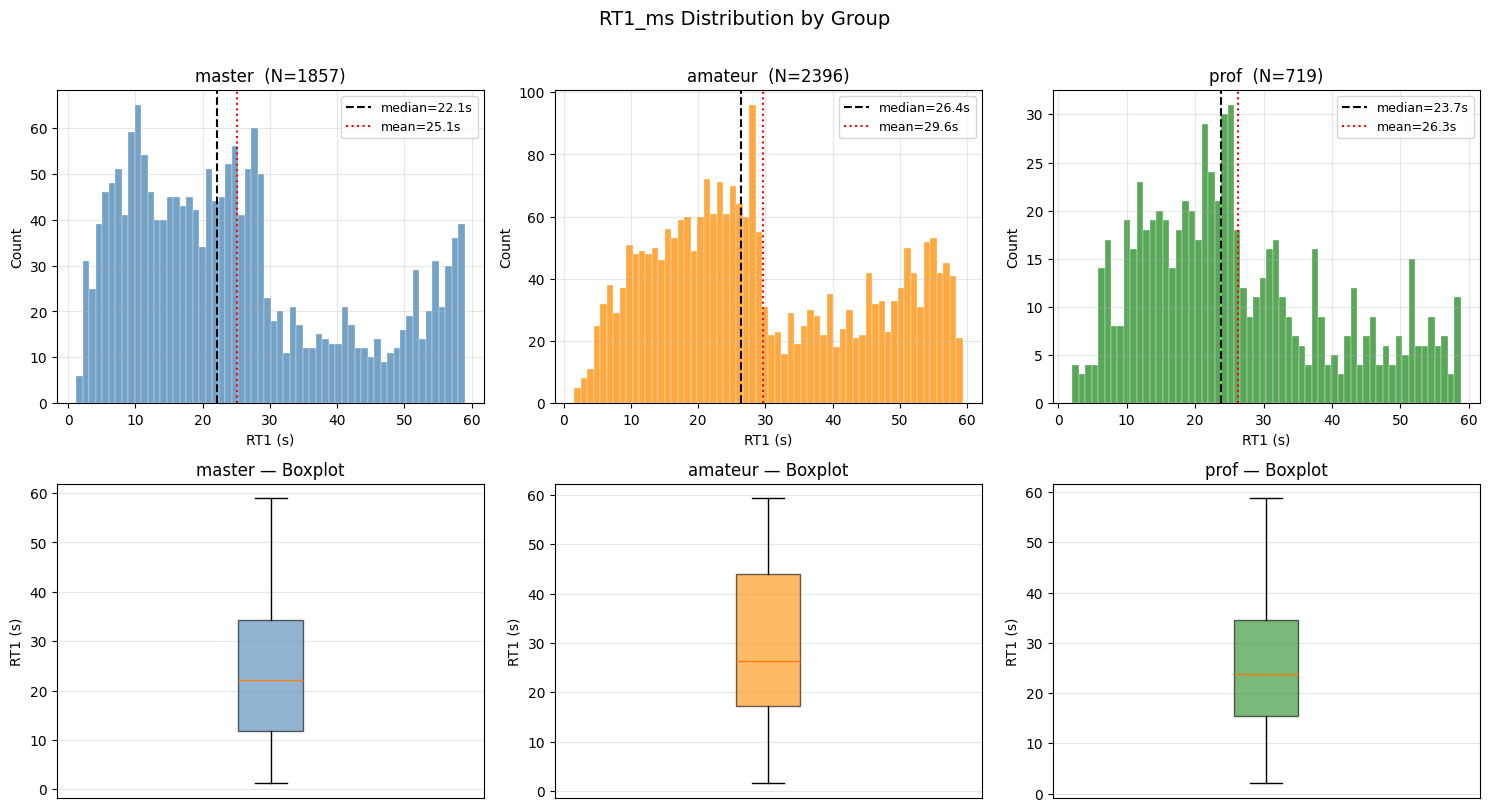

In [4]:
# ── 分布視覺化（histogram + boxplot）──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, g in enumerate(GROUPS):
    rt = df_trials[df_trials['Group'] == g]['RT1_ms'].dropna()
    color = COLORS[g]

    # Histogram
    ax = axes[0, col]
    ax.hist(rt / 1000, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(rt.median() / 1000, color='black', linestyle='--', lw=1.5, label=f'median={rt.median()/1000:.1f}s')
    ax.axvline(rt.mean() / 1000,   color='red',   linestyle=':',  lw=1.5, label=f'mean={rt.mean()/1000:.1f}s')
    ax.set_title(f'{g}  (N={len(rt)})', fontsize=12)
    ax.set_xlabel('RT1 (s)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Boxplot
    ax2 = axes[1, col]
    bp = ax2.boxplot(rt / 1000, vert=True, patch_artist=True,
                     flierprops=dict(marker='.', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.6)
    ax2.set_title(f'{g} — Boxplot', fontsize=12)
    ax2.set_ylabel('RT1 (s)')
    ax2.set_xticks([])
    ax2.grid(alpha=0.3)

plt.suptitle('RT1_ms Distribution by Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\rt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

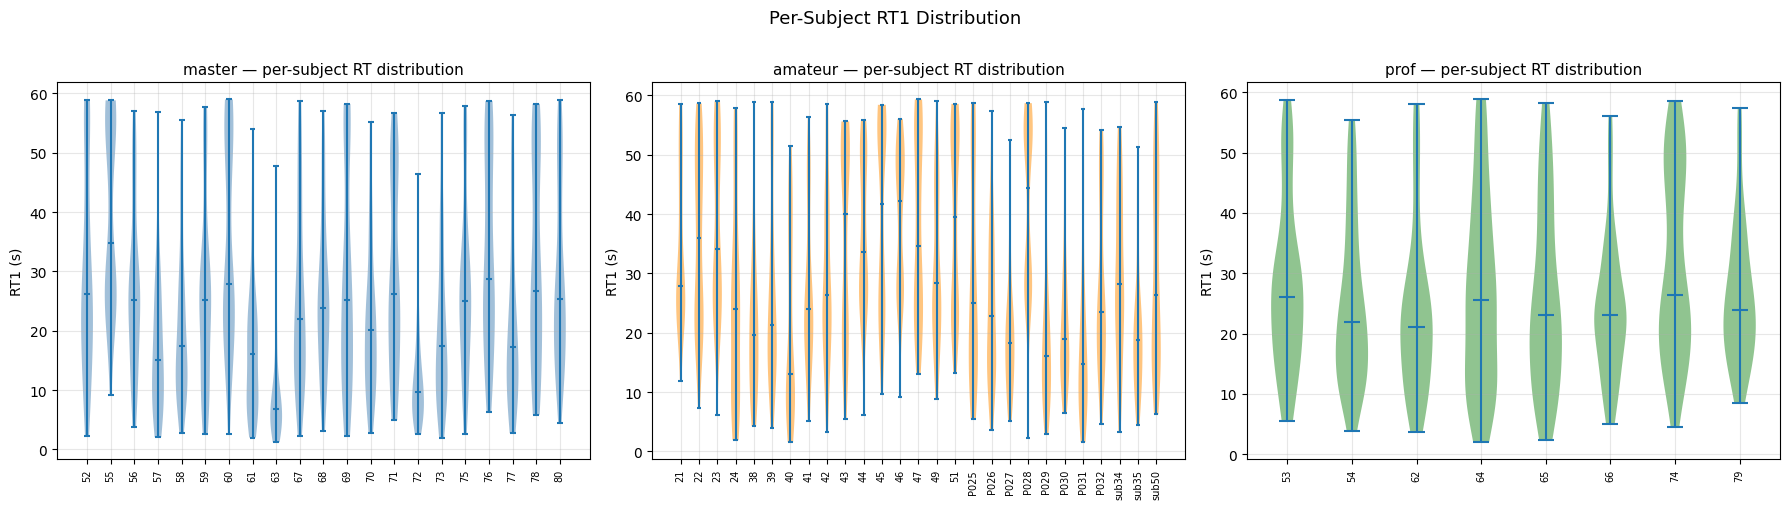

In [5]:
# ── 各 Subject 的 RT 分布（violin plot）── 
# 看個體差異有多大
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, g in enumerate(GROUPS):
    df_g = df_trials[df_trials['Group'] == g].dropna(subset=['RT1_ms'])
    subs = sorted(df_g['SubjectID'].unique())
    data = [df_g[df_g['SubjectID'] == s]['RT1_ms'].values / 1000 for s in subs]

    ax = axes[col]
    parts = ax.violinplot(data, positions=range(len(subs)), showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(COLORS[g])
        pc.set_alpha(0.5)

    ax.set_xticks(range(len(subs)))
    ax.set_xticklabels([s.replace('sub-', '') for s in subs], rotation=90, fontsize=7)
    ax.set_title(f'{g} — per-subject RT distribution', fontsize=11)
    ax.set_ylabel('RT1 (s)')
    ax.grid(alpha=0.3)

plt.suptitle('Per-Subject RT1 Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\rt_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── 異常值分析：IQR 法（per-subject）──
# 對每個 subject 各自計算 IQR fence，避免個體均值差異影響判斷

records = []
for g in GROUPS:
    df_g = df_trials[df_trials['Group'] == g].dropna(subset=['RT1_ms'])
    for sub, grp in df_g.groupby('SubjectID'):
        rt = grp['RT1_ms']
        q1, q3 = rt.quantile(0.25), rt.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((rt < lo) | (rt > hi)).sum()
        records.append({
            'Group': g, 'SubjectID': sub,
            'n_trials': len(rt),
            'median': rt.median(),
            'IQR': iqr,
            'fence_lo': lo, 'fence_hi': hi,
            'n_outlier': n_out,
            'pct_outlier': 100 * n_out / len(rt),
        })

df_out = pd.DataFrame(records)
print('=== Per-Subject IQR Outlier 統計 ===')
print(df_out.groupby('Group')[['n_trials','n_outlier','pct_outlier']]
      .agg({'n_trials':'sum', 'n_outlier':'sum', 'pct_outlier':'mean'})
      .round(2))
print()
print('異常值比例最高的 10 個 subject：')
print(df_out.nlargest(10, 'pct_outlier')
      [['Group','SubjectID','n_trials','n_outlier','pct_outlier','median','fence_hi']]
      .to_string(index=False))

=== Per-Subject IQR Outlier 統計 ===
         n_trials  n_outlier  pct_outlier
Group                                    
amateur      2396         27         1.12
master       1857         30         1.60
prof          719         12         1.67

異常值比例最高的 10 個 subject：
  Group SubjectID  n_trials  n_outlier  pct_outlier  median  fence_hi
amateur  sub-P029        90          8     8.888889 16067.0  46202.00
 master    sub-63        88          6     6.818182  6770.0  21419.25
amateur  sub-P027        89          6     6.741573 18278.0  39520.00
amateur sub-sub35        90          6     6.666667 18770.0  42935.00
 master    sub-70        90          5     5.555556 20082.0  49585.00
   prof    sub-62        90          5     5.555556 21135.0  55406.00
 master    sub-72        90          4     4.444444  9692.0  26432.25
   prof    sub-79        90          4     4.444444 23911.0  52076.00
amateur  sub-P030        89          3     3.370787 18964.0  51594.00
 master    sub-57        90    

In [7]:
# ── 異常值處理：per-subject IQR clip，並存成乾淨的 trial 清單 ──
# 策略：移除（而非 clip），因為回歸任務中異常 RT 可能對應異常行為而非純雜訊

clean_rows = []
for g in GROUPS:
    df_g = df_trials[df_trials['Group'] == g].dropna(subset=['RT1_ms'])
    for sub, grp in df_g.groupby('SubjectID'):
        rt = grp['RT1_ms']
        q1, q3 = rt.quantile(0.25), rt.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (rt >= lo) & (rt <= hi)
        clean_rows.append(grp[mask.values])

df_clean = pd.concat(clean_rows).reset_index(drop=True)

print('=== 清理前後 trial 數 ===')
for g in GROUPS:
    n_before = len(df_trials[df_trials['Group'] == g].dropna(subset=['RT1_ms']))
    n_after  = len(df_clean[df_clean['Group'] == g])
    print(f'[{g}]  {n_before} → {n_after}  (移除 {n_before - n_after}, {100*(n_before-n_after)/n_before:.1f}%)')

# 儲存乾淨的 trial key（Group, SubjectID, Session, Epoch）供後續使用
out_path = r'd:\Tseng\game_eeg\RT1_ms_predict\clean_trial_keys.csv'
df_clean[['Group','SubjectID','Session','Epoch','RT1_ms']].to_csv(out_path, index=False)
print(f'\n已儲存清理後的 trial key：{out_path}')

=== 清理前後 trial 數 ===
[master]  1857 → 1827  (移除 30, 1.6%)
[amateur]  2396 → 2369  (移除 27, 1.1%)
[prof]  719 → 707  (移除 12, 1.7%)

已儲存清理後的 trial key：d:\Tseng\game_eeg\RT1_ms_predict\clean_trial_keys.csv
